In [85]:
import pandas as pd
from pathlib import Path

# from posydon.popsyn.binarypopulation import BinaryPopulation
# from posydon.binary_evol.binarystar import BinaryStar
# from posydon.binary_evol.singlestar import SingleStar
from posydon.popsyn.synthetic_population import Population
# from posydon.popsyn.synthetic_population import PopulationRunner
# import astropy.units as u
# 
# import os
# import shutil
# from posydon.config import PATH_TO_POSYDON

from POSYDONHRDiagramModule import HR_Diagram

import matplotlib.pyplot as plt

import random as rand 

from collections import Counter

DataPath = Path().resolve().parent / 'Data'


In [74]:
cols = ['time', 'step_names', 'state', 'event', 'S1_state', 'S2_state', 'S1_mass', 'S2_mass', 'orbital_period']
finCols = [
    'orbital_period_f',
    'eccentricity_f',
    'state_f',

    'S1_state_f',
    'S2_state_f',
    
    'S2_mass_f',
    'S2_log_R_f',
    'S2_log_L_f',


    'S1_mass_f',
    'S1_log_R_f',
    'S1_log_L_f'

 ]

initCols = [
    'orbital_period_i',
    'eccentricity_i',
    'state_i',

    'S2_state_i',
    'S2_mass_i',
    'S2_log_R_i',

    'S1_state_i',
    'S1_mass_i',
    'S1_log_R_i'
 ]

In [75]:
def basicColHist(df, var:str, title:str|None = None, xLabel:str|None = None, saveFig:bool = False) -> None:

    fig, ax = plt.subplots(figsize = (8,5))
    
    ax.hist(df[var], bins = 50)

    if title == None: 
        title = f'{var} of BH-Sol systems at inital detached state'
    ax.set_title(title)    

    if xLabel == None:
        xLabel = var 
    ax.set_xlabel(xLabel)
    ax.set_ylabel('count')

    if saveFig == True:
        plt.savefig(title.replace(' ', '_')) 
    
    return plt.show() 

In [76]:
pop = Population(str(DataPath / 'bhSol_10Gyr_LowPorb_Subpop.h5'))

In [77]:
Counter(pop.formation_channels['channel'])

Counter({'ZAMS_oCE1_CC1_oRLO2_CC2_maxtime_END': 23,
         'ZAMS_oRLO1_CC1_END': 13,
         'ZAMS_oCE1_CC1_END': 11,
         'ZAMS_oRLO1-contact_CC1_END': 10,
         'ZAMS_oCE1_CC1_oRLO2_CC2_END': 5,
         'ZAMS_oRLO1_CC1_oRLO2_oCE2_oMerging2_END': 3,
         'ZAMS_oCE1_CC1_oRLO2_oCE2_oMerging2_END': 2,
         'ZAMS_oRLO1-reverse_CC1_END': 2,
         'ZAMS_oRLO1_CC1_oRLO2_CC2_maxtime_END': 1})

In [78]:
pOneline = pop.oneline.select()
pHistory = pop.history.select()

In [79]:
bhSolRows = pd.read_csv(DataPath / 'threeDayPorb_solBHPairRows.csv')

In [80]:
bhSolRows

,binary_index,state,event,time,separation,orbital_period,eccentricity,rl_relative_overflow_1,rl_relative_overflow_2,lg_mtransfer_rate,...,S2_conv_env_turnover_time_l_b,S2_conv_env_turnover_time_l_t,S2_envelope_binding_energy,S2_mass_conv_reg_fortides,S2_thickness_conv_reg_fortides,S2_radius_conv_reg_fortides,S2_lambda_CE_1cent,S2_lambda_CE_10cent,S2_lambda_CE_30cent,S2_lambda_CE_pure_He_star_10cent
0,247,detached,NaN,9.005453e+09,17.260173,2.597624,0.731268,NaN,NaN,NaN,...,0.000000e+00,0.000000e+00,-4.920224e+49,1.751981e-01,0.053072,1.714441,1.500545,1.500545,1.500545,1.506050
1,582,detached,NaN,1.095540e+10,13.974633,1.460274,0.081986,NaN,NaN,NaN,...,2.068964e+00,-1.000000e+99,-7.742313e+49,3.215535e-07,0.028851,4.691799,1.310448,1.310448,1.310448,1.310448
2,703,detached,NaN,1.071638e+10,25.639921,2.895749,0.258043,NaN,NaN,NaN,...,-7.814006e+98,-7.814006e+98,-1.570231e+50,6.267881e-01,0.248905,6.461539,1.492789,1.492789,1.289354,1.497068
3,2029,detached,NaN,9.467351e+09,22.757058,2.399101,0.413139,NaN,NaN,NaN,...,-9.740103e+98,-1.000000e+99,-1.554792e+50,1.760771e-06,0.156886,7.867052,1.472960,1.472960,1.472960,1.473763
4,2086,detached,NaN,9.179265e+09,17.787168,2.581370,0.394472,NaN,NaN,NaN,...,-1.737363e+91,-1.000000e+99,-5.697924e+49,1.409217e-07,0.012028,3.940619,1.266923,1.266923,1.266923,1.266923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,37932,detached,NaN,9.790867e+09,15.224047,2.092048,0.235246,NaN,NaN,NaN,...,-3.106424e+91,-1.000000e+99,-4.582246e+49,1.308894e-09,0.005746,3.376193,1.264025,1.264025,1.264025,1.264025
66,38056,detached,NaN,9.258820e+09,12.733134,1.565752,0.180059,NaN,NaN,NaN,...,-2.060157e+91,-1.000000e+99,-4.935613e+49,1.369782e-09,0.006161,3.554741,1.268890,1.268890,1.268890,1.268890
67,38116,detached,NaN,9.836158e+09,25.862374,2.993418,0.351462,NaN,NaN,NaN,...,-7.053111e+98,-7.053111e+98,-1.500950e+50,1.097844e-01,0.119667,5.947732,1.518408,1.518408,1.518408,1.520201
68,39010,detached,NaN,1.069579e+10,20.500913,2.474185,0.942151,NaN,NaN,NaN,...,-2.670562e+98,-2.670562e+98,-1.083366e+50,3.404900e-06,0.210447,6.851214,1.185381,1.185381,1.185381,1.212819


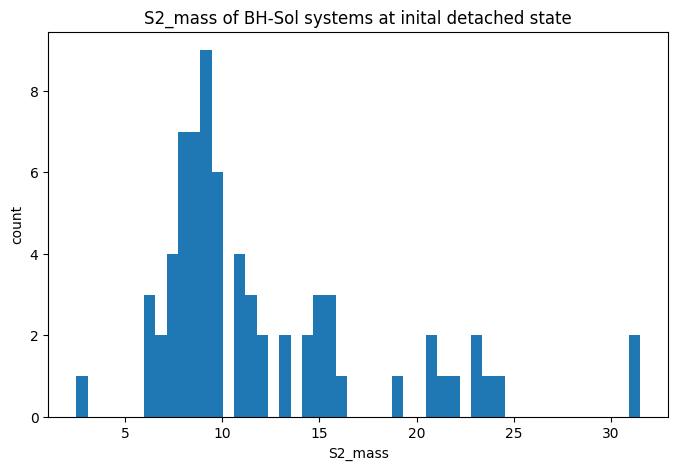

In [81]:
basicColHist(bhSolRows,'S2_mass')

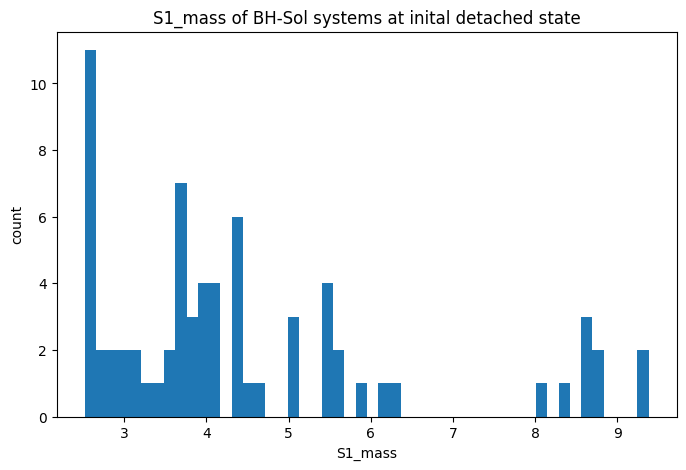

In [82]:
basicColHist(bhSolRows,'S1_mass')

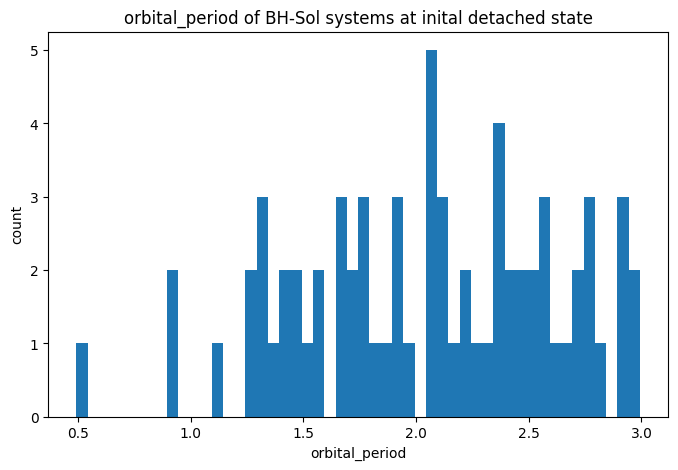

In [83]:
basicColHist(bhSolRows,'orbital_period', saveFig=True)


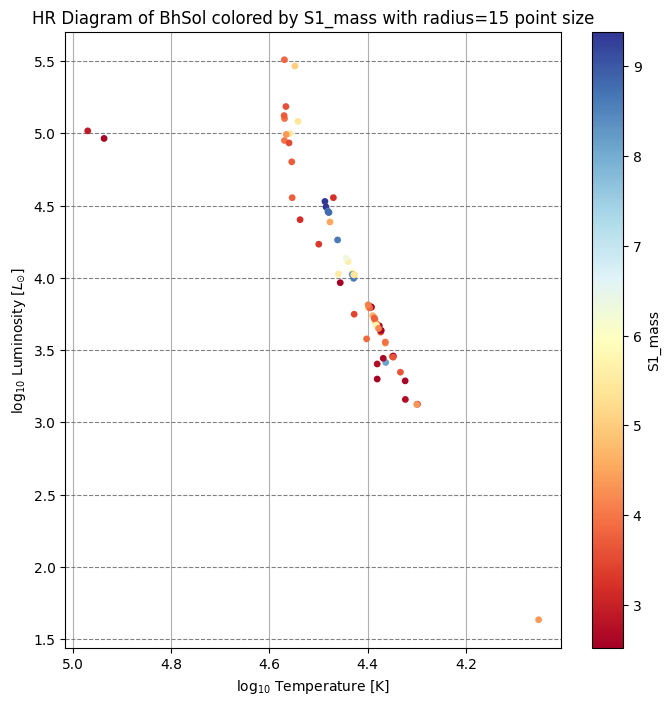

In [84]:
HR_Diagram(bhSolRows,
           'BhSol',
           Star_Radius=15)